# App Version Changelog Scraper — 11 Fintech & Bank Apps (iOS)

Scrapes the **full version-history / changelog** ("What's New") for **Revolut, Klarna, Wise, Starling, Tide, Monzo, ANNA Bank, Lloyds, NatWest, Barclays and HSBC**
from the **Apple App Store**, filtered to the **past 12 months**.

**Why iOS-only?** Google Play exposes no per-version changelog history publicly (Android "What's New"
text only ever covers the latest update), so this notebook focuses on Apple, whose store front serves
the complete per-version history.

**Source.** The store's web app renders version history client-side via Apple's internal
`amp-api.apps.apple.com` endpoint, which requires a signed JWT bearer token. However, the store front
serves the **identical JSON** through a **token-free reverse proxy** at
`apps.apple.com/api/apps/v1/catalog/...`, so no token handling is required — a browser `User-Agent`
header is enough. Apple caps the history at **25 entries per app**.

**Environment.** Run with the `fintech-app-reviews` kernel (project venv). Only `requests`, `pandas` and
`matplotlib` are needed.

> **Dataset alignment.** This notebook is kept in sync with `scrape_app_reviews.ipynb` and `data/reviews_all.csv`,
> which now cover the same 11 apps. The original 3-app version (Revolut/Klarna/Wise) has been expanded to include
> **Starling, Tide, Monzo, ANNA Bank, Lloyds, NatWest, Barclays and HSBC**.


In [1]:
import html
import json
import os
import re
import time
from datetime import datetime, timedelta

import requests
import pandas as pd

pd.set_option("display.max_colwidth", 100)

## 1. Configuration

`MONTHS` sets the look-back window applied to each release date. `COUNTRY`/`LANG` are the Apple
storefront code and language — note the UK storefront code is **`gb`**, not `uk`. Per-app checkpoints
land in `data/raw/ios_<app>.csv` (one file per app, 11 total) and the final combined dataset goes to `data/ios_changelogs.csv`.


In [2]:
MONTHS   = 12            # look-back window in months
COUNTRY  = "gb"          # Apple storefront code (UK = "gb", NOT "uk")
LANG     = "en-GB"
DATA_DIR = "data"
RAW_DIR  = os.path.join(DATA_DIR, "raw")
OUT_PATH = os.path.join(DATA_DIR, "ios_changelogs.csv")
SLEEP    = 0.5           # seconds between app requests

os.makedirs(RAW_DIR, exist_ok=True)

CUTOFF = datetime.now() - timedelta(days=int(365 * MONTHS / 12))
print("Keeping changelog entries released on/after", CUTOFF.date())

APPS = {
    "Revolut": 932493382,
    "Klarna":  1115120118,
    "Wise":    612261027,
    "Starling":  956806430,   # Starling Bank
    "Tide":      1140086177,  # Tide Business Banking
    "Monzo":     1052238659,  # Monzo
    "ANNA Bank": 1333008275,  # ANNA Money
    "Lloyds":    469964520,   # Lloyds Mobile Banking
    "NatWest":   334855322,   # NatWest Mobile Banking
    "Barclays":  536248734,   # Barclays
    "HSBC":      1220329065,  # HSBC UK Mobile Banking (bundle uk.co.hsbc.hsbcukmobilebanking) — note: old id 1200273760 now 404, corrected via iTunes Search 2026-08-23
}

for app, app_id in APPS.items():
    print(f"  {app}: iOS app id {app_id}")


Keeping changelog entries released on/after 2025-08-23
  Revolut: iOS app id 932493382
  Klarna: iOS app id 1115120118
  Wise: iOS app id 612261027
  Starling: iOS app id 956806430
  Tide: iOS app id 1140086177
  Monzo: iOS app id 1052238659
  ANNA Bank: iOS app id 1333008275
  Lloyds: iOS app id 469964520
  NatWest: iOS app id 334855322
  Barclays: iOS app id 536248734
  HSBC: iOS app id 1220329065


## 2. iOS version-history adapter

`fetch_ios_version_history(app_id)` GETs the token-free store-front proxy and returns the raw
`versionHistory` array. Each entry carries `externalVersionId`, `releaseDate`, `releaseNotes`,
`releaseTimestamp` and `versionDisplay`. A small retry loop (3 attempts, 5s apart) absorbs transient
network errors; if the `ios` platform block is missing the function returns `[]`.


In [3]:
USER_AGENT = ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
              "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36")


def fetch_ios_version_history(app_id):
    url = (f"https://apps.apple.com/api/apps/v1/catalog/{COUNTRY}/apps/{app_id}"
           f"?platform=iphone&extend=versionHistory&l={LANG}")
    headers = {"User-Agent": USER_AGENT, "Accept": "application/json"}

    last_err = None
    for attempt in range(1, 4):
        try:
            r = requests.get(url, headers=headers, timeout=30)
            r.raise_for_status()
            attrs = r.json()["data"][0]["attributes"]["platformAttributes"]
            ios = attrs.get("ios")
            if ios is None:
                return []
            return ios.get("versionHistory", [])
        except requests.exceptions.RequestException as e:
            last_err = e
            print(f"  ! attempt {attempt}/3 failed: {e}")
            time.sleep(5)
    raise last_err

## 3. Normalisation & windowing

Maps the raw `versionHistory` entries into one tidy schema (`COLS`). `norm_ios()` is the per-entry
mapper; `load_existing()`/`save_progress()` provide the same resumable checkpoint behaviour as the
review scraper notebook (dedupe key = `(app, version)` tuple).


In [4]:
COLS = ["platform", "app", "version", "release_date", "release_notes",
        "external_version_id", "scraped_at"]


def norm_ios(app, v):
    return {
        "platform": "app_store",
        "app": app,
        "version": v.get("versionDisplay"),
        "release_date": v.get("releaseDate"),
        "release_notes": v.get("releaseNotes"),
        "external_version_id": v.get("externalVersionId"),
        "scraped_at": datetime.now().isoformat(timespec="seconds"),
    }


def load_existing(path):
    """Return (rows, seen_versions) from a previously saved checkpoint CSV."""
    if os.path.exists(path) and os.path.getsize(path) > 0:
        df = pd.read_csv(path)
        if len(df):
            seen = set(zip(df["app"], df["version"].astype(str)))
            return df.to_dict("records"), seen
    return [], set()


def save_progress(path, rows):
    pd.DataFrame(rows, columns=COLS).to_csv(path, index=False)

## 4. Run the scraper

One request per app (**11 total**) — the store-front proxy caps version history at 25 entries per app (≤275 rows overall). Entries are
kept only when `releaseDate >= CUTOFF.date()`, which is a plain string comparison on the `YYYY-MM-DD`
date. Checkpoints are written to `data/raw/ios_<app>.csv` so a re-run resumes instead of duplicating.

> **New apps (2026-08):** Starling, Tide, Monzo, ANNA Bank, Lloyds, NatWest, Barclays and HSBC were added to match the expanded
> `reviews_all.csv` dataset. Existing `ios_Revolut/Klarna/Wise.csv` checkpoints are reused; only the 8 new apps require fresh fetches on first run.


In [5]:
all_rows = []
for app, app_id in APPS.items():
    path = os.path.join(RAW_DIR, f"ios_{app}.csv")
    rows, seen = load_existing(path)

    history = fetch_ios_version_history(app_id)
    kept = []
    for v in history:
        release_date = v.get("releaseDate") or ""
        if release_date < str(CUTOFF.date()):
            continue
        key = (app, v.get("versionDisplay"))
        if key in seen:
            continue
        seen.add(key)
        kept.append(norm_ios(app, v))

    rows.extend(kept)
    save_progress(path, rows)
    print(f"[{app}] fetched {len(history)}, kept {len(kept)}")

    all_rows.extend(rows)
    time.sleep(SLEEP)

print(f"\nCollected {len(all_rows)} rows total")

[Revolut] fetched 25, kept 0
[Klarna] fetched 25, kept 0
[Wise] fetched 25, kept 0
[Starling] fetched 25, kept 0
[Tide] fetched 25, kept 0
[Monzo] fetched 25, kept 0
[ANNA Bank] fetched 25, kept 0
[Lloyds] fetched 25, kept 0
[NatWest] fetched 25, kept 0
[Barclays] fetched 25, kept 0
[HSBC] fetched 25, kept 0

Collected 256 rows total


## 5. Combine, clean and save

Concats the per-app checkpoints into one DataFrame, parses `release_date`, drops anything before the
cutoff, removes duplicate `(app, version)` pairs, sorts by app then release date, and writes the final
CSV to `data/ios_changelogs.csv`.


In [6]:
frames = []
for app in APPS:
    path = os.path.join(RAW_DIR, f"ios_{app}.csv")
    if os.path.exists(path) and os.path.getsize(path) > 0:
        frames.append(pd.read_csv(path))

df = pd.concat(frames, ignore_index=True)

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
df = df[df["release_date"] >= pd.Timestamp(CUTOFF.date())]
df = df.drop_duplicates(subset=["app", "version"]).reset_index(drop=True)
df = df.sort_values(["app", "release_date"], ignore_index=True)

df.to_csv(OUT_PATH, index=False)
print(f"Saved {len(df)} rows to {OUT_PATH}")

Saved 256 rows to data/ios_changelogs.csv


## 6. Quick overview

Summary statistics: releases per app, the total, and the actual date span covered by the dataset.


In [7]:
print("=== Releases per app ===")
print(df.groupby("app", observed=True).size().to_string())
print("\n=== Total releases ===")
print(len(df))
print("\n=== Date range ===")
print("Earliest:", df["release_date"].min().date(), "| Latest:", df["release_date"].max().date())
print("\n=== Preview ===")
display(df.head(10))

=== Releases per app ===
app
ANNA Bank    25
Barclays     19
HSBC         21
Klarna       27
Lloyds       23
Monzo        25
NatWest      14
Revolut      25
Starling     25
Tide         25
Wise         27

=== Total releases ===
256

=== Date range ===
Earliest: 2025-08-26 | Latest: 2026-08-21

=== Preview ===


,platform,app,version,release_date,release_notes,external_version_id,scraped_at
0,app_store,ANNA Bank,1.144.0,2025-11-26,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",880062789,2026-08-23T15:46:02
1,app_store,ANNA Bank,1.145.0,2025-12-15,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",880325264,2026-08-23T15:46:02
2,app_store,ANNA Bank,1.146.0,2025-12-20,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",880693630,2026-08-23T15:46:02
3,app_store,ANNA Bank,1.146.1,2026-01-07,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",881224064,2026-08-23T15:46:02
4,app_store,ANNA Bank,1.146.2,2026-01-08,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",881290282,2026-08-23T15:46:02
5,app_store,ANNA Bank,1.147.0,2026-01-23,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",881539694,2026-08-23T15:46:02
6,app_store,ANNA Bank,1.148.0,2026-01-30,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",881769483,2026-08-23T15:46:02
7,app_store,ANNA Bank,1.149.0,2026-02-16,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",882089024,2026-08-23T15:46:02
8,app_store,ANNA Bank,1.150.0,2026-02-27,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",882520490,2026-08-23T15:46:02
9,app_store,ANNA Bank,1.151.0,2026-03-10,"Bug fixes and performance improvements\n\nFor support or guidance, email us at support@anna.money",883012127,2026-08-23T15:46:02


## 7. Chart — release cadence by app

For each app, the **cumulative count of releases over time** — a step plot whose height at any date
equals the number of versions shipped up to that point. Steeper lines mean faster shipping; the flats
between steps are the release gaps.


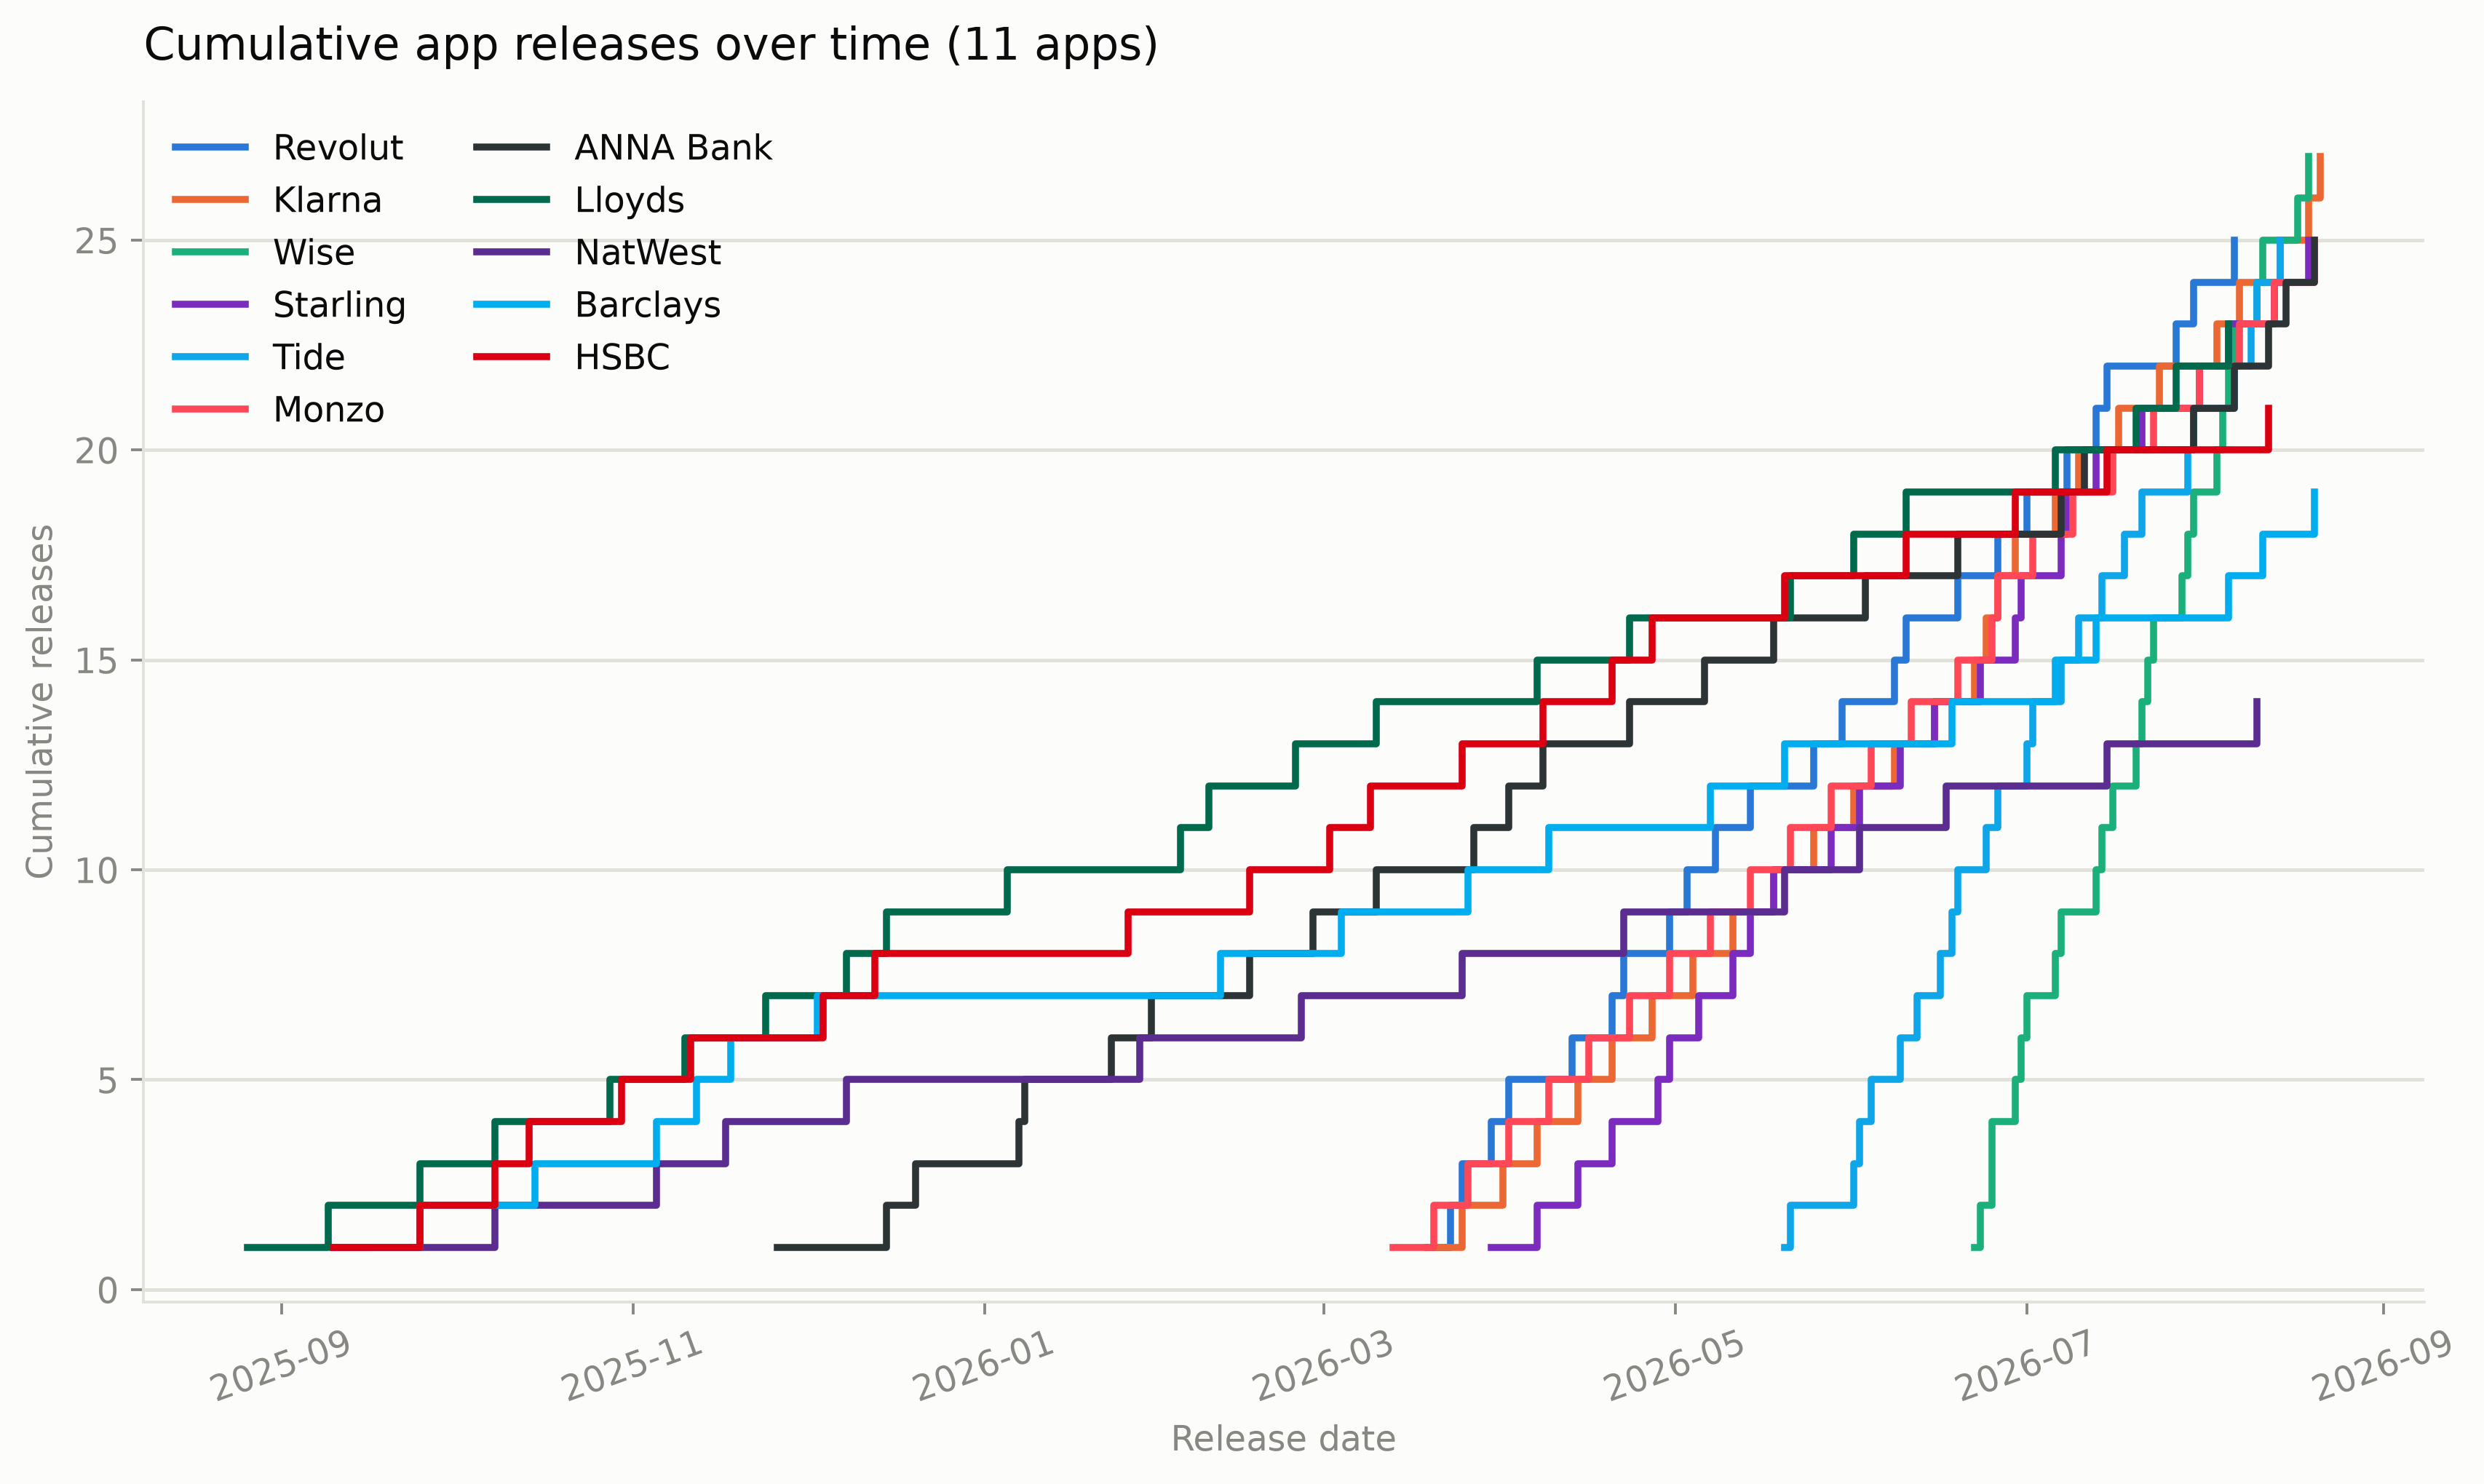

In [8]:
import matplotlib.pyplot as plt

APP_COLORS = {
    "Revolut": "#2a78d6",   # blue
    "Klarna": "#eb6834",    # orange
    "Wise": "#1baf7a",      # teal
    "Starling": "#7b2cbf",  # purple
    "Tide": "#0ea5e9",      # sky
    "Monzo": "#ff4757",     # coral/red
    "ANNA Bank": "#2d3436", # dark grey
    "Lloyds": "#006a4d",    # lloyds green
    "NatWest": "#5c2d91",   # natwest purple
    "Barclays": "#00aeef",  # barclays cyan
    "HSBC": "#db0011",      # hsbc red
}
INK      = "#0b0b0b"
MUTED    = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE  = "#fcfcfb"

if df.empty:
    print("No data to plot — run the scraper cells above first.")
else:
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    for app in APPS:
        sub = df[df["app"] == app].sort_values("release_date")
        if sub.empty:
            continue
        ax.step(sub["release_date"], range(1, len(sub) + 1), where="post",
                color=APP_COLORS.get(app, "#333333"), label=app, linewidth=2)

    ax.set_xlabel("Release date", color=MUTED, fontsize=10)
    ax.set_ylabel("Cumulative releases", color=MUTED, fontsize=10)
    ax.tick_params(axis="x", colors=MUTED, rotation=20)
    ax.tick_params(axis="y", colors=MUTED)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.spines["left"].set_color(GRIDLINE)

    ax.set_title("Cumulative app releases over time (11 apps)", color=INK, fontsize=13, loc="left", pad=12)
    ax.legend(frameon=False, labelcolor=INK, ncol=2)

    plt.tight_layout()
    plt.show()
